In [1]:
%pylab inline

# import warnings;
# warnings.filterwarnings('ignore');

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
# from mpl_toolkits.mplot3d import Axes3D

from matplotlib import rc
rc('text', usetex=True)
# rc('font', family='Times New Roman', size='20')
fontsize = 22
params = {
    'font.family': 'Times New Roman',
#     'font.weight': 150,
    'font.size': fontsize,
    'axes.titlesize': fontsize,
    'axes.labelsize': fontsize ,
    'xtick.labelsize': fontsize-2,
    'ytick.labelsize': fontsize-2,
    'legend.fontsize': fontsize-5,
}
rcParams.update(params)

Duplicate key in file '/Users/chigamma/.matplotlib/matplotlibrc' line #2.

Bad key "“backend" on line 2 in
/Users/chigamma/.matplotlib/matplotlibrc.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.3/matplotlibrc.template
or from the matplotlib source distribution


Populating the interactive namespace from numpy and matplotlib


In [2]:
import os
import argparse
import re

In [3]:
def geteacc(acc_lst, acc=80):
    for i, v in enumerate(acc_lst):
        if v >= acc:
            break
    return i

def comm(siz_lst, i, cn=10):
    res = 0
    for client in range(cn):
        res += sum(siz_lst[client][:i+1])
    return res

def commE(siz_lst, cn=10):
    res = 0
    for client in range(cn):
        res += sum(siz_lst[client][:200])
        if len(siz_lst[client]) > 200:
            print("Warning")
    return res

def get_onef(d, f, epc=200):
    path_save = os.path.join("../../save/", d, f)
    file_log = os.path.join(path_save, 'log.txt')
#     print(file_log)
    with open(file_log, 'r') as fil:
        s = fil.read()
    
    loss_lst, acc_lst = [], []
    it = re.finditer(
        r'\[Server\]  Test Loss: (\d+\.\d+),  Accuracy: (\d+\.\d+)', s)
    for i in it:
        loss_lst.append(float(i.group(1)))
        acc_lst.append(100 * float(i.group(2)))
    if len(acc_lst) != epc:
        print("Warning", d, f, len(acc_lst))
        acc_lst = acc_lst[:epc]

    siz_lst = {}
    for client in range(10):
        it = re.finditer(
            r'\[Client  {}\]  Param Before: \d+\.\d+e\+\d+,  After: (\d+\.\d+e\+\d+)'.format(client), s)
        siz_lst[client] = []
        for i in it:
            siz_lst[client].append(float(i.group(1)))
            
    comm_lst = [0]
    for i in range(epc):
        comm = comm_lst[i]
        for c in range(10):
            comm += siz_lst[c][i]
        comm_lst.append(comm)
    
    dic = {'f': f,
           'loss': [max(loss_lst)]+loss_lst,
           'acc': [10]+acc_lst,
           'siz': siz_lst,
           'comm': comm_lst}
    return dic

def get_oneb(d, f, siz, epc=200):
    path_save = os.path.join("../../save/", d, f)
    file_log = os.path.join(path_save, 'log.txt')
#     print(file_log)
    with open(file_log, 'r') as fil:
        s = fil.read()
    
    loss_lst, acc_lst = [], []
    it = re.finditer(
        r'\[Server\]  Test Loss: (\d+\.\d+),  Accuracy: (\d+\.\d+)', s)
    for i in it:
        loss_lst.append(float(i.group(1)))
        acc_lst.append(100 * float(i.group(2)))
    if len(acc_lst) != epc:
#         print("Warning", d, f, len(acc_lst))
        acc_lst = acc_lst[:epc]

    siz_lst = {}
    for client in range(10):
        siz_lst[client] = [siz] * epc

    comm_lst = [0]
    for i in range(epc):
        comm = comm_lst[i]
        for c in range(10):
            comm += siz_lst[c][i]
        comm_lst.append(comm)

    dic = {'f': f,
           'loss': [max(loss_lst)]+loss_lst,
           'acc': [10]+acc_lst,
           'siz': siz_lst,
           'comm': comm_lst}
    return dic

In [39]:
issave = True

## ASI Acc

In [6]:
dv = {}
drr = 'PowerAvg'
flst = ['0505-51e86b', '0505-c91b68', '0518-7f7b8d', '0503-8d365b', 
        '0503-96b3c1', '0518-705e39', '0519-9cba0b']
nlst = ['64', '32', '16', '8',
        '4', '2', '1']
for f, n in zip(flst, nlst):
    dv[n] = get_onef(drr, f)

drr = 'PruneAvg'
flst = ['0503-4e666b', '0527-c7c0e6', '0507-6fad97',
        '0502-e9de2d', '0503-abceca', '0529-66f883', '0527-1e387b']
nlst = ['p16', 'p4', 'p1', # 1%, 0.2%, 0.1%
        '10p', '4p', '2p', '05p'] 
for f, n in zip(flst, nlst):
    dv[n] = get_onef(drr, f)

drr = 'AlsAvg'
flst = ['0523-8edac7', '0523-14af53', '0523-a06cd1', 
        '0523-0edc5e', '0527-d4b659', '0526-a23a2a', 
        '0529-bb54b7', '0529-a30d66', 
        '0523-d44712', '0523-eedc00', '0527-415732', '0526-c8ec45',
        '0529-d195c7', '0529-3e3f2c', 
        '0601-73f79c', '0601-3f9d7a', '0601-90867c', '0601-868d9e'] 
nlst = ['301', '302', '304',
        '305', '307', '310',
        '315', '320', 
        '101', '105', '107', '110',
        '115', '120',
        '805', '810', '815', '820',] 
for f, n in zip(flst, nlst):
    dv[n] = get_onef(drr, f)

dv['b'] = get_oneb('FedAvg', '0311-60ca75', siz=1.3430e8)

In [70]:
dr = {}
drr = 'PowerAvg'
flst = ['0519-79097c', '0519-75d28a', '0619-561f9a', '0519-6c8d3e', 
        '0426-865fb2', '0426-7c9d84', '0427-cd764a', '0519-340954']
nlst = ['64', '32', '48', '16', 
        '8',  '4', '2', '1']
for f, n in zip(flst, nlst):
    dr[n] = get_onef(drr, f)
    
flst = ['0623-53d3f7', '0623-188ae5', '0623-d8d0aa', '0623-023de3', 
        '0623-fee33d', '0623-50fa10', '0623-d07f23', '0623-c744dd']
nlst = ['l64', 'l32', 'l48', 'l16', 
        'l8',  'l4', 'l2', 'l1']
for f, n in zip(flst, nlst):
    dr[n] = get_onef(drr, f)
    
drr = 'PruneAvg'
flst = ['0527-3a7ff6', '0525-7ed5c0',
        '0525-41ce82', '0525-280c6e', '0526-11301f', ]
nlst = ['20p', '10p',  # 20, 10%
       'p16', 'p4', 'p1' ]  # 5%, 1%, 0.5%
for f, n in zip(flst, nlst):
    dr[n] = get_onef(drr, f)
    
drr = 'AlsAvg'
flst = ['0525-c940e7', '0525-1a0093', '0526-e15ac0', '0530-074763',
        '0529-2b0a9f', '0529-e8b4a9', 
        '0525-74cf3c', '0525-99de1a', '0525-1a9123', 
        '0525-06407e', '0526-614727', '0530-e9db16',
        '0529-e128c1', '0529-fddde1', 
        '0531-12bc62', '0531-2797ea', '0529-58170c', '0529-11730a', ]
nlst = ['301', '305', '307', '310',
        '315', '320',
        '101', '102', '104', 
        '105', '107', '110',
        '115', '120',
        '805', '810', '815', '820',] 
for f, n in zip(flst, nlst):
    dr[n] = get_onef(drr, f)

flst = ['0703-5791cb', '0703-b1cb97', '0703-14155d', '0703-e0dbb9', 
        '0704-29d250', '0704-b44154', '0704-44a592', '0704-58728c', ]
nlst = ['l105', 'l110', 'l115', 'l120',
        'l805', 'l810', 'l815', 'l820',] 
for f, n in zip(flst, nlst):
    dr[n] = get_onef(drr, f)

dr['b'] = get_oneb('FedAvg', '0311-60ca75', siz=1.1184e7)
dr['b2'] = get_oneb('FedAvg', '0619-2585af', siz=1.1184e7)

In [26]:
cm = plt.cm.tab20(np.arange(0, 20))
st = {'ls': '-', 'lw': 4, 'marker': 'o', 'ms': 12, 'alpha': 0.85}
st2 = {'ls': '--', 'lw': 4, 'marker': 'o', 'ms': 12, 'alpha': 0.85}
sp = {'ls': '-', 'lw': 4, 'marker': 'D', 'ms': 12, 'alpha': 0.8}

In [31]:
acb = 94.36 # max(dr['b']['acc'])
acb2 = max(dr['b2']['acc'])
c8b = dr['b']['comm'][10]
ceb = dr['b']['comm'][200]
szb = dr['b']['siz'][0][0]

nlst = ['64', '48', '32', '16', '8', '4', '2', '1']
rt_l = [dr[n]['siz'][0][0] / szb * 100 for n in nlst]
ac_l = [max(dr[n]['acc']) for n in nlst]
c8_l = [dr[n]['comm'][geteacc(dr[n]['acc'], acc=80)] for n in nlst]
ce_l = [dr[n]['comm'][200] for n in nlst]

nlst = ['l64', 'l32', 'l48', 'l16', 'l8',  'l4', 'l2', 'l1']
rtl_l = [dr[n]['siz'][0][0] / szb * 100 for n in nlst]
acl_l = [max(dr[n]['acc']) for n in nlst]
c8l_l = [dr[n]['comm'][geteacc(dr[n]['acc'], acc=80)] for n in nlst]
cel_l = [dr[n]['comm'][200] for n in nlst]

nlst = ['20p', '10p', 'p16', 'p4', 'p1']
rtp_l = [20.1, 10.1, 5.2, 1.2, 0.671]
acp_l = [max(dr[n]['acc']) for n in nlst]
c8p_l = [dr[n]['comm'][geteacc(dr[n]['acc'], acc=80)] for n in nlst]
cep_l = [dr[n]['comm'][200] for n in nlst]

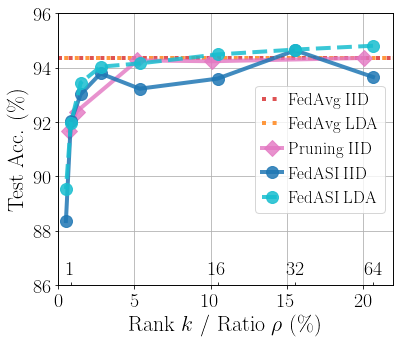

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax2 = ax.twiny()

ax.plot([0, 25], [acb, acb], c=cm[6], label='FedAvg IID', 
        ls=':', lw=4, alpha=0.8)
ax.plot([-1, 25], [acb, acb], c=cm[2], label='FedAvg LDA', 
        ls=':', lw=4, alpha=0.8)

ax.plot(rtp_l, acp_l, c=cm[12], label='Pruning IID', **sp)
ax.plot(rt_l, ac_l, c=cm[0], label='FedASI IID', **st)
ax.plot(rtl_l, acl_l, c=cm[18], label='FedASI LDA', **st2)

ax2.set(xlim=[0, 22], 
        xticks=[rt_l[0], rt_l[1], rt_l[2], rt_l[6]], 
        xticklabels=['64', '32', '16', '1'])
ax.set(xlim=[0, 22], ylim=[86, 96], 
       xlabel='Rank $k$ / Ratio $\\rho$ (\%)', ylabel='Test Acc. (\%)')
ax2.xaxis.tick_bottom()
ax2.tick_params(axis='x', direction='in', pad=-25)
ax.grid(True, axis='y')
ax.grid(True, which='both', axis='x')

ax.legend(ncol=1, loc=5, 
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_5asiper_accVrk_rsn.pdf', bbox_inches='tight')

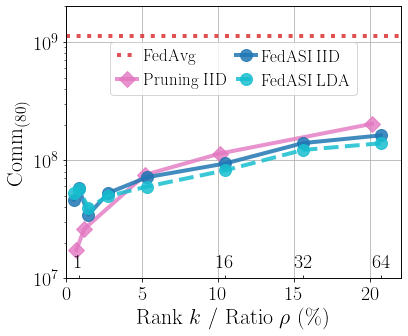

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax2 = ax.twiny()

ax.semilogy([0, 25], [c8b, c8b], c=cm[6], label='FedAvg', 
            ls=':', lw=4, alpha=0.8)

ax.semilogy(rtp_l, c8p_l, c=cm[12], label='Pruning IID', **sp)
ax.semilogy(rt_l, c8_l, c=cm[0], label='FedASI IID', **st)
ax.semilogy(rtl_l, c8l_l, c=cm[18], label='FedASI LDA', **st2)

ax2.set(xlim=[0, 22], 
        xticks=[rt_l[0], rt_l[1], rt_l[2], rt_l[6]], 
        xticklabels=['64', '32', '16', '1'])
ax.set(xlim=[0, 22], ylim=[1e7, 2e9], 
       xlabel='Rank $k$ / Ratio $\\rho$ (\%)', ylabel='$\\mathrm{Comm_{(80)}}$')
ax2.xaxis.tick_bottom()
ax2.tick_params(axis='x', direction='in', pad=-25)
ax.grid(True, axis='y')
ax.grid(True, which='both', axis='x')

ax.legend(ncol=2, loc=9, bbox_to_anchor=[0.5, 0.9],
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_5asiper_cm8Vrk_rsn.pdf', bbox_inches='tight')

## ALS

In [71]:
nlst = ['16', '101', '102', '104', '105', '110', '115', '120',]
rt_l = [0, 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 2.0]
ac_l = [max(dr[n]['acc']) for n in nlst]
c8_l = [dr[n]['comm'][geteacc(dr[n]['acc'], acc=80)] for n in nlst]
ce_l = [dr[n]['comm'][200] for n in nlst]

nlst = ['32', '301', '305', '310', '315', '320',]
rt3_l = [0, 0.1, 0.5, 1.0, 1.5, 2.0]
ac3_l = [max(dr[n]['acc']) for n in nlst]
c83_l = [dr[n]['comm'][geteacc(dr[n]['acc'], acc=80)] for n in nlst]
ce3_l = [dr[n]['comm'][200] for n in nlst]

nlst = ['8', '805', '810', '815', '820',]
rt8_l = [0, 0.5, 1.0, 1.5, 2.0]
ac8_l = [max(dr[n]['acc']) for n in nlst]
c88_l = [dr[n]['comm'][geteacc(dr[n]['acc'], acc=80)] for n in nlst]
ce8_l = [dr[n]['comm'][200] for n in nlst]

nlst = ['l16', 'l105', 'l110', 'l115', 'l120',]
rt1l_l = [0, 0.5, 1.0, 1.5, 2.0]
ac1l_l = [max(dr[n]['acc']) for n in nlst]
c81l_l = [dr[n]['comm'][geteacc(dr[n]['acc'], acc=80)] for n in nlst]
ce1l_l = [dr[n]['comm'][200] for n in nlst]

nlst = ['l8', 'l805', 'l810', 'l815', 'l820',]
rt8l_l = [0, 0.5, 1.0, 1.5, 2.0]
ac8l_l = [max(dr[n]['acc']) for n in nlst]
c88l_l = [dr[n]['comm'][geteacc(dr[n]['acc'], acc=80)] for n in nlst]
ce8l_l = [dr[n]['comm'][200] for n in nlst]

In [72]:
lb = ['FedAvg IID', 
      'FedALS IID $k=32$', 
      'FedALS IID $k=16$', 
      'FedALS IID $k=8$', 
      'FedALS LDA $k=16$', 
      'FedALS LDA $k=8$', ]

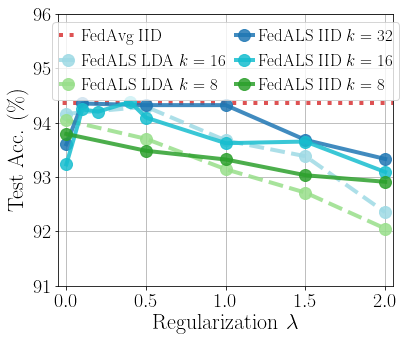

In [75]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.plot([-10, 25], [acb, acb], c=cm[6], label=lb[0], 
        ls=':', lw=4, alpha=0.8)
ax.plot(rt1l_l, ac1l_l, c=cm[19], label=lb[4], **st2)
ax.plot(rt8l_l, ac8l_l, c=cm[5] , label=lb[5], **st2)

ax.plot(rt3_l, ac3_l, c=cm[0] , label=lb[1], **st)
ax.plot(rt_l , ac_l , c=cm[18], label=lb[2], **st)
ax.plot(rt8_l, ac8_l, c=cm[4] , label=lb[3], **st)

ax.set(xlim=[-0.05, 2.05], ylim=[91, 96], 
       xlabel='Regularization $\\lambda$', ylabel='Test Acc. (\%)')
ax.grid(True, axis='y')
ax.grid(True, which='both', axis='x')

ax.legend(ncol=2, loc=9, 
          columnspacing=0.6, handlelength=1., handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_5alsper_accVrk_rsn.pdf', bbox_inches='tight')

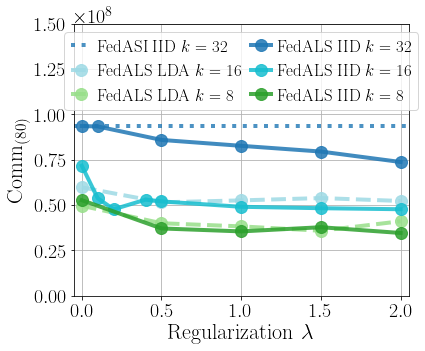

In [78]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

# ax.plot([-10, 25], [c8b, c8b], c=cm[6], label=lb[0], 
#             ls='--', lw=4, alpha=0.8)
ax.plot([-10, 25], [c83_l[0], c83_l[0]], c=cm[0], label='FedASI IID $k=32$', 
            ls=':', lw=4, alpha=0.8)
ax.plot(rt1l_l, c81l_l, c=cm[19], label=lb[4], **st2)
ax.plot(rt8l_l, c88l_l, c=cm[5] , label=lb[5], **st2)

ax.plot(rt3_l, c83_l, c=cm[0] , label=lb[1], **st)
ax.plot(rt_l , c8_l , c=cm[18], label=lb[2], **st)
ax.plot(rt8_l, c88_l, c=cm[4] , label=lb[3], **st)

ax.set(xlim=[-0.05, 2.05], ylim=[0, 1.5e8], 
       xlabel='Regularization $\\lambda$', ylabel='$\\mathrm{Comm_{(80)}}$')
ax.grid(True, axis='y')
ax.grid(True, which='both', axis='x')

ax.legend(ncol=2, loc=9, 
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_5alsper_cm8Vrk_rsn.pdf', bbox_inches='tight')